# Dzień 5 — Rozszerzenia: VIX, korelacje, timeline, model recesji

**Nowe elementy:**
1. **VIX** — indeks strachu, dane z yfinance → baza SQLite
2. **Heatmapa korelacji** — które wskaźniki chodzą razem?
3. **Timeline inwersji → recesji** — wizualna oś czasu
4. **Logistic Regression** — prawdopodobieństwo recesji 0–100%

**Dane:** `data/fed_cycles.db` → widok `v_master`

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DB_PATH = Path('../data/fed_cycles.db')
RAW_DIR = Path('../data/raw')
REP_DIR = Path('../reports')

conn = sqlite3.connect(DB_PATH)

# Wczytaj v_master
df = pd.read_sql('SELECT * FROM v_master ORDER BY ym', conn)
df['ym'] = pd.to_datetime(df['ym'])
df = df.set_index('ym').sort_index()

# Wskaźniki pochodne (te same co w 04)
df['m2_yoy']    = df['m2sl'].pct_change(12) * 100
df['cpi_yoy']   = df['cpiaucsl'].pct_change(12) * 100
df['real_rate']  = df['fedfunds'] - df['cpi_yoy']
df['sp500_yoy']  = df['sp500'].pct_change(12) * 100

print(f'Zakres: {df.index.min().strftime("%Y-%m")} → {df.index.max().strftime("%Y-%m")} ({len(df)} miesięcy)')
df.tail(3)

Zakres: 1990-01 → 2026-09 (441 miesięcy)


,fedfunds,m2sl,sp500,t10y2y,usrec,unrate,gdpc1,cpiaucsl,m2_yoy,cpi_yoy,real_rate,sp500_yoy
ym,,,,,,,,,,,,
2026-07-01,3.63,23218.0,7481.339091,0.376818,0.0,4.1,NaN,332.813,5.414179,3.303856,0.326144,18.817458
2026-08-01,3.63,NaN,7711.323333,0.468095,0.0,4.1,NaN,334.131,NaN,3.353016,0.276984,20.321174
2026-09-01,NaN,NaN,7665.367500,0.396250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.423852


---
## 1. VIX — indeks strachu

VIX (CBOE Volatility Index) mierzy oczekiwaną zmienność S&P500 w ciągu 30 dni.
- **< 15** — spokój, brak stresu
- **15–25** — normalny niepokój
- **25–35** — strach, korekta
- **> 35** — panika (COVID, GFC)

Pobieramy z Yahoo Finance (`^VIX`), agregujemy do średniej miesięcznej i dodajemy do bazy.

In [2]:
import yfinance as yf

print('Pobieranie VIX (^VIX) z Yahoo Finance...')
vix_raw = yf.download('^VIX', start='1990-01-01', progress=False)

# Średnia miesięczna
vix_monthly = (
    vix_raw['Close']
    .resample('MS').mean()
    .reset_index()
)
vix_monthly.columns = ['date', 'value']
vix_monthly['date'] = vix_monthly['date'].dt.strftime('%Y-%m-%d')
vix_monthly['series_id'] = 'VIX'
vix_monthly = vix_monthly.dropna()

print(f'Pobrano: {len(vix_monthly)} miesięcy ({vix_monthly["date"].iloc[0]} → {vix_monthly["date"].iloc[-1]})')
print(f'Min: {vix_monthly["value"].min():.1f}  Max: {vix_monthly["value"].max():.1f}')

# Zapis do CSV
vix_monthly.to_csv(RAW_DIR / 'VIX.csv', index=False)

# Dodaj do bazy SQLite
conn.execute("DELETE FROM raw_series WHERE series_id = 'VIX'")
vix_monthly.to_sql('raw_series', conn, if_exists='append', index=False)
conn.commit()

n = conn.execute("SELECT COUNT(*) FROM raw_series WHERE series_id='VIX'").fetchone()[0]
print(f'VIX w bazie: {n} wierszy')

Pobieranie VIX (^VIX) z Yahoo Finance...


Pobrano: 441 miesięcy (1990-01-01 → 2026-09-01)
Min: 10.1  Max: 62.6
VIX w bazie: 441 wierszy


In [3]:
# Aktualizuj v_master — dodaj kolumnę VIX
conn.execute('DROP VIEW IF EXISTS v_master')

conn.execute("""
CREATE VIEW v_master AS
WITH monthly AS (
    SELECT
        strftime('%Y-%m', date) AS ym,
        series_id,
        AVG(value) AS value
    FROM raw_series
    GROUP BY ym, series_id
)
SELECT
    ym,
    MAX(CASE WHEN series_id = 'FEDFUNDS'       THEN value END) AS fedfunds,
    MAX(CASE WHEN series_id = 'M2SL'           THEN value END) AS m2sl,
    MAX(CASE WHEN series_id = 'SP500'          THEN value END) AS sp500,
    MAX(CASE WHEN series_id = 'T10Y2Y'        THEN value END) AS t10y2y,
    MAX(CASE WHEN series_id = 'USREC'         THEN value END) AS usrec,
    MAX(CASE WHEN series_id = 'UNRATE'        THEN value END) AS unrate,
    MAX(CASE WHEN series_id = 'GDPC1'         THEN value END) AS gdpc1,
    MAX(CASE WHEN series_id = 'CPIAUCSL'      THEN value END) AS cpiaucsl,
    MAX(CASE WHEN series_id = 'ICSA'          THEN value END) AS icsa,
    MAX(CASE WHEN series_id = 'PAYEMS'        THEN value END) AS payems,
    MAX(CASE WHEN series_id = 'INDPRO'        THEN value END) AS indpro,
    MAX(CASE WHEN series_id = 'RSXFS'         THEN value END) AS rsxfs,
    MAX(CASE WHEN series_id = 'PERMIT'        THEN value END) AS permit,
    MAX(CASE WHEN series_id = 'BAMLH0A0HYM2'  THEN value END) AS hy_spread,
    MAX(CASE WHEN series_id = 'DRTSCILM'      THEN value END) AS credit_cond,
    MAX(CASE WHEN series_id = 'USSLIND'       THEN value END) AS lei,
    MAX(CASE WHEN series_id = 'VIX'           THEN value END) AS vix
FROM monthly
GROUP BY ym
ORDER BY ym
""")
conn.commit()

# Przeładuj dane z nowym VIX
df = pd.read_sql('SELECT * FROM v_master ORDER BY ym', conn)
df['ym'] = pd.to_datetime(df['ym'])
df = df.set_index('ym').sort_index()

# Pochodne
df['m2_yoy']    = df['m2sl'].pct_change(12) * 100
df['cpi_yoy']   = df['cpiaucsl'].pct_change(12) * 100
df['real_rate']  = df['fedfunds'] - df['cpi_yoy']
df['sp500_yoy']  = df['sp500'].pct_change(12) * 100

vix_data = df['vix'].dropna()
print(f'VIX w v_master: {len(vix_data)} miesięcy')
print(f'Aktualny VIX ({vix_data.index[-1].strftime("%Y-%m")}): {vix_data.iloc[-1]:.1f}')
print(f'Percentyl: {stats.percentileofscore(vix_data, vix_data.iloc[-1], kind="rank"):.0f}.')

VIX w v_master: 441 miesięcy
Aktualny VIX (2026-09): 15.7
Percentyl: 36.


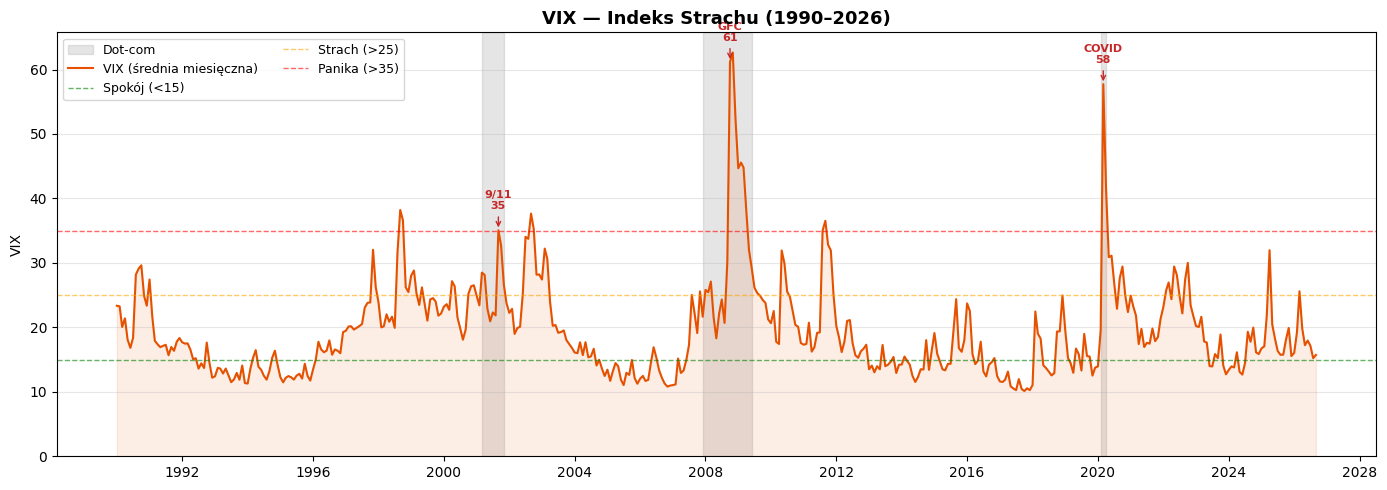

Zapisano: reports/05_vix.png


In [4]:
# Wykres VIX z zaznaczonymi recesjami i progami
recesje_df = pd.read_sql('SELECT * FROM dim_recession', conn)

fig, ax = plt.subplots(figsize=(14, 5))

# Szare pasy recesji
for _, r in recesje_df.iterrows():
    ax.axvspan(pd.Timestamp(r['start']), pd.Timestamp(r['end']),
               color='gray', alpha=0.2, label=r['name'] if _ == 0 else '')

# VIX
vix = df['vix'].dropna()
ax.plot(vix.index, vix, color='#E65100', linewidth=1.5, label='VIX (średnia miesięczna)')
ax.fill_between(vix.index, 0, vix, alpha=0.1, color='#E65100')

# Progi
ax.axhline(15, color='green', linestyle='--', linewidth=1, alpha=0.6, label='Spokój (<15)')
ax.axhline(25, color='orange', linestyle='--', linewidth=1, alpha=0.6, label='Strach (>25)')
ax.axhline(35, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Panika (>35)')

# Etykiety szczytów
peaks = [
    ('2008-10', 'GFC'),
    ('2020-03', 'COVID'),
    ('2001-09', '9/11'),
]
for date_str, label in peaks:
    date = pd.Timestamp(date_str)
    if date in vix.index:
        val = vix.loc[date]
        ax.annotate(f'{label}\n{val:.0f}', xy=(date, val), xytext=(0, 15),
                    textcoords='offset points', ha='center', fontsize=8,
                    fontweight='bold', color='#C62828',
                    arrowprops=dict(arrowstyle='->', color='#C62828', lw=1))

ax.set_ylabel('VIX')
ax.set_title('VIX — Indeks Strachu (1990–2026)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.set_ylim(0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/05_vix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Zapisano: reports/05_vix.png')

---
## 2. Heatmapa korelacji wskaźników

Które wskaźniki chodzą razem, a które dają niezależne sygnały?
Wysoka korelacja = redundancja, niska = niezależna informacja.
Dobry scorecard powinien używać wskaźników o niskiej wzajemnej korelacji.

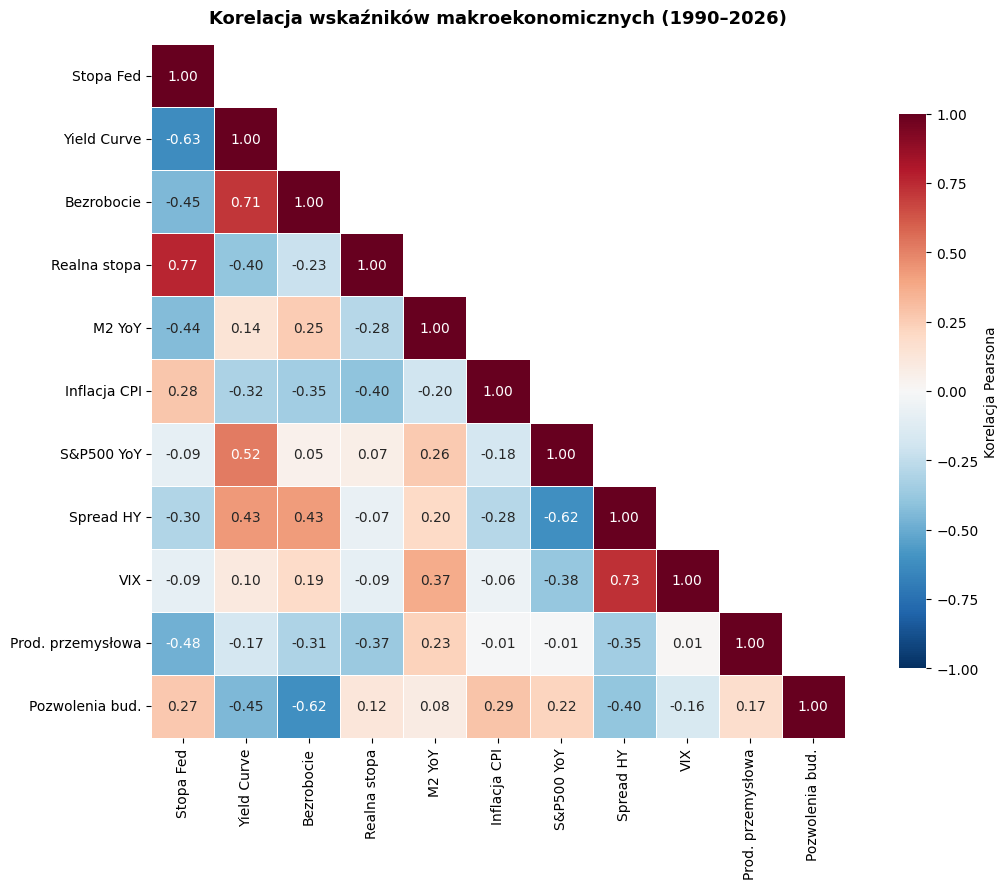

Zapisano: reports/06_korelacje.png


In [5]:
# Wybór wskaźników do korelacji — mix poziomów i dynamik
corr_cols = {
    'fedfunds':  'Stopa Fed',
    't10y2y':    'Yield Curve',
    'unrate':    'Bezrobocie',
    'real_rate':  'Realna stopa',
    'm2_yoy':    'M2 YoY',
    'cpi_yoy':   'Inflacja CPI',
    'sp500_yoy': 'S&P500 YoY',
    'hy_spread': 'Spread HY',
    'vix':       'VIX',
    'indpro':    'Prod. przemysłowa',
    'permit':    'Pozwolenia bud.',
}

# Filtruj dostępne kolumny
available = {k: v for k, v in corr_cols.items() if k in df.columns}
corr_df = df[list(available.keys())].dropna(how='all')
corr_matrix = corr_df.corr(method='pearson')
corr_matrix.index = [available[c] for c in corr_matrix.index]
corr_matrix.columns = [available[c] for c in corr_matrix.columns]

# Heatmapa
fig, ax = plt.subplots(figsize=(12, 9))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Korelacja Pearsona'},
    ax=ax
)

ax.set_title('Korelacja wskaźników makroekonomicznych (1990–2026)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/06_korelacje.png', dpi=150, bbox_inches='tight')
plt.show()
print('Zapisano: reports/06_korelacje.png')

In [6]:
# Interpretacja — najsilniejsze korelacje
print('=== TOP korelacje (|r| > 0.4) ===\n')
pairs = []
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.4:
            pairs.append((corr_matrix.index[i], corr_matrix.columns[j], r))

pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for a, b, r in pairs:
    kierunek = '↑↑ razem' if r > 0 else '↑↓ odwrotnie'
    print(f'  {a:<20} × {b:<20} r={r:+.2f}  ({kierunek})')

print(f'\n=== Wskaźniki NIEZALEŻNE od reszty (wszystkie |r| < 0.3) ===\n')
for col in corr_matrix.columns:
    others = corr_matrix[col].drop(col)
    if others.abs().max() < 0.3:
        print(f'  {col} — max |r| = {others.abs().max():.2f} → niezależny sygnał')

=== TOP korelacje (|r| > 0.4) ===

  Stopa Fed            × Realna stopa         r=+0.77  (↑↑ razem)
  Spread HY            × VIX                  r=+0.73  (↑↑ razem)
  Yield Curve          × Bezrobocie           r=+0.71  (↑↑ razem)
  Stopa Fed            × Yield Curve          r=-0.63  (↑↓ odwrotnie)
  Bezrobocie           × Pozwolenia bud.      r=-0.62  (↑↓ odwrotnie)
  S&P500 YoY           × Spread HY            r=-0.62  (↑↓ odwrotnie)
  Yield Curve          × S&P500 YoY           r=+0.52  (↑↑ razem)
  Stopa Fed            × Prod. przemysłowa    r=-0.48  (↑↓ odwrotnie)
  Yield Curve          × Pozwolenia bud.      r=-0.45  (↑↓ odwrotnie)
  Stopa Fed            × Bezrobocie           r=-0.45  (↑↓ odwrotnie)
  Stopa Fed            × M2 YoY               r=-0.44  (↑↓ odwrotnie)
  Yield Curve          × Spread HY            r=+0.43  (↑↑ razem)
  Bezrobocie           × Spread HY            r=+0.43  (↑↑ razem)
  Realna stopa         × Inflacja CPI         r=-0.40  (↑↓ odwrotnie)

=== Wska

---
## 3. Timeline inwersji krzywej → recesji

Wizualna oś czasu: kiedy yield curve się odwracała i ile miesięcy później przychodziła recesja.
Używamy logiki z notebooka 03 (Q2 naprawione w Pythonie).

In [7]:
# Identyfikacja inwersji i recesji
yc = df[['t10y2y', 'usrec']].dropna()

# Początki inwersji (przejście z >= 0 na < 0)
yc['prev_t10y2y'] = yc['t10y2y'].shift(1)
inwersje_start = yc[(yc['t10y2y'] < 0) & (yc['prev_t10y2y'] >= 0)].index.tolist()

# Końce inwersji (przejście z < 0 na >= 0)
inwersje_end = yc[(yc['t10y2y'] >= 0) & (yc['prev_t10y2y'] < 0)].index.tolist()

# Początki i końce recesji
yc['prev_usrec'] = yc['usrec'].shift(1)
recesje_start = yc[(yc['usrec'] == 1) & (yc['prev_usrec'] == 0)].index.tolist()
recesje_end_dates = yc[(yc['usrec'] == 0) & (yc['prev_usrec'] == 1)].index.tolist()

# Grupuj inwersje w epizody (łącz te bliższe niż 6 miesięcy)
episodes = []
for s in inwersje_start:
    ends_after = [e for e in inwersje_end if e > s]
    end = ends_after[0] if ends_after else df.index[-1]
    if episodes and (s - episodes[-1]['end']).days < 180:
        episodes[-1]['end'] = end
    else:
        episodes.append({'start': s, 'end': end})

# Nazwy recesji — mapowane po dacie startu
rec_name_map = {}
for _, r in recesje_df.iterrows():
    rec_name_map[pd.Timestamp(r['start'])] = r['name']
# Dodaj recesję 1990 (nie ma jej w dim_recession)
rec_name_map[pd.Timestamp('1990-08-01')] = 'Gulf War (1990)'

def get_rec_name(rec_start):
    """Znajdź nazwę recesji po dacie startu (tolerancja ±60 dni)."""
    for ts, name in rec_name_map.items():
        if abs((rec_start - ts).days) < 60:
            return name
    return f'Recesja {rec_start.strftime("%Y-%m")}'

# Parowanie: dla każdej recesji → ostatnia inwersja PRZED nią (max 36 mies.)
used_episodes = set()
pary = []

for i, rs in enumerate(recesje_start):
    re = recesje_end_dates[i] if i < len(recesje_end_dates) else rs + pd.DateOffset(months=6)
    name = get_rec_name(rs)
    
    best_ep = None
    for j, ep in enumerate(episodes):
        if j in used_episodes:
            continue
        diff = round((rs - ep['start']).days / 30)
        if 0 < diff <= 36 and ep['start'] < rs:
            best_ep = (j, ep, diff)
    
    if best_ep:
        j, ep, months = best_ep
        used_episodes.add(j)
        pary.append({
            'inv_start': ep['start'], 'inv_end': ep['end'],
            'rec_start': rs, 'rec_end': re,
            'months': months, 'name': name
        })

# Ostatnia inwersja (2022) — bez recesji
for j, ep in enumerate(episodes):
    if j not in used_episodes and ep['start'] >= pd.Timestamp('2020-01-01'):
        pary.append({
            'inv_start': ep['start'], 'inv_end': ep['end'],
            'rec_start': None, 'rec_end': None,
            'months': None, 'name': 'Brak recesji (soft landing?)'
        })

print(f'Znaleziono {len(episodes)} epizodów inwersji, {len(pary)} par:\n')
for p in pary:
    inv = f"{p['inv_start'].strftime('%Y-%m')} → {p['inv_end'].strftime('%Y-%m')}"
    if p['rec_start']:
        print(f"  Inwersja {inv}  →  {p['name']} ({p['months']} mies.)")
    else:
        print(f"  Inwersja {inv}  →  {p['name']}")

Znaleziono 5 epizodów inwersji, 4 par:

  Inwersja 1990-03 → 1990-04  →  Gulf War (1990) (5 mies.)
  Inwersja 2000-02 → 2001-01  →  Dot-com (14 mies.)
  Inwersja 2006-02 → 2007-06  →  GFC (23 mies.)
  Inwersja 2022-07 → 2024-09  →  Brak recesji (soft landing?)


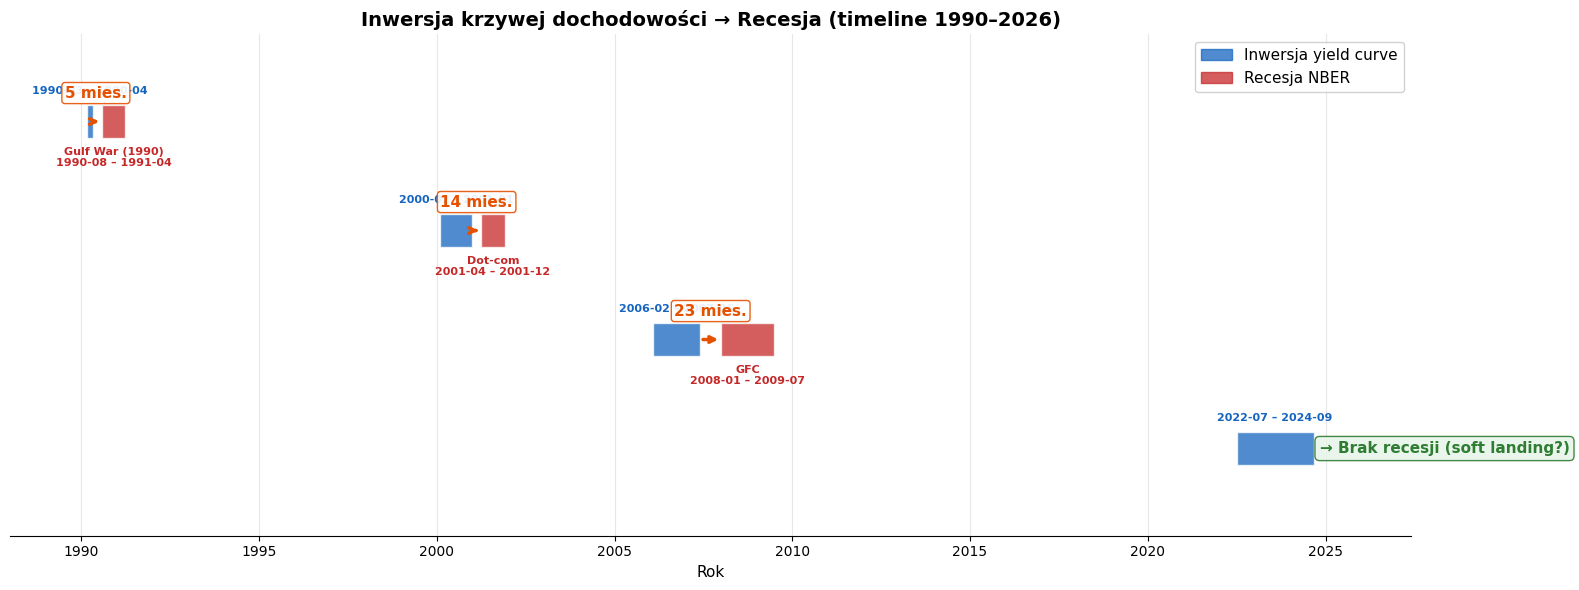

Zapisano: reports/07_timeline_inwersja_recesja.png


In [8]:
# Timeline — wizualizacja (etykiety nad paskami)
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(16, 6))

colors_inv = '#1565C0'
colors_rec = '#C62828'
colors_arrow = '#E65100'
bar_h = 0.3

for i, p in enumerate(pary):
    y = len(pary) - 1 - i

    inv_start_num = mdates.date2num(p['inv_start'])
    inv_end_num = mdates.date2num(p['inv_end'])
    inv_width = inv_end_num - inv_start_num
    inv_width = max(inv_width, 60)

    # Pasek inwersji (niebieski)
    ax.broken_barh([(inv_start_num, inv_width)], (y - bar_h/2, bar_h),
                   facecolors=colors_inv, alpha=0.75, edgecolors='white', linewidth=1)
    # Etykieta NAD paskiem
    ax.text(inv_start_num + inv_width/2, y + bar_h/2 + 0.08,
            f"{p['inv_start'].strftime('%Y-%m')} – {p['inv_end'].strftime('%Y-%m')}",
            ha='center', va='bottom', fontsize=8, color=colors_inv, fontweight='bold')

    if p['rec_start'] is not None:
        rec_start_num = mdates.date2num(p['rec_start'])
        rec_end_num = mdates.date2num(p['rec_end'])
        rec_width = rec_end_num - rec_start_num
        rec_width = max(rec_width, 60)

        # Pasek recesji (czerwony)
        ax.broken_barh([(rec_start_num, rec_width)], (y - bar_h/2, bar_h),
                       facecolors=colors_rec, alpha=0.75, edgecolors='white', linewidth=1)
        # Etykieta POD paskiem
        ax.text(rec_start_num + rec_width/2, y - bar_h/2 - 0.08,
                f"{p['name']}\n{p['rec_start'].strftime('%Y-%m')} – {p['rec_end'].strftime('%Y-%m')}",
                ha='center', va='top', fontsize=8, color=colors_rec, fontweight='bold')

        # Strzałka z liczbą miesięcy
        mid_arrow = inv_end_num + (rec_start_num - inv_end_num) / 2
        if rec_start_num - inv_end_num > 30:
            ax.annotate('', xy=(rec_start_num, y), xytext=(inv_end_num, y),
                        arrowprops=dict(arrowstyle='->', color=colors_arrow, lw=2.5))
        ax.text(mid_arrow, y + 0.22, f'{p["months"]} mies.',
                ha='center', fontsize=11, fontweight='bold', color=colors_arrow,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=colors_arrow, alpha=0.9))
    else:
        # Brak recesji — zielona etykieta
        ax.text(inv_end_num + 60, y,
                f'→ {p["name"]}',
                ha='left', va='center', fontsize=11, fontweight='bold', color='#2E7D32',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F5E9', edgecolor='#2E7D32', alpha=0.9))

# Oś X — margines po lewej żeby etykiety się nie ucinały
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
x_min = mdates.date2num(pd.Timestamp('1988-01-01'))
x_max = mdates.date2num(pd.Timestamp('2027-06-01'))
ax.set_xlim(x_min, x_max)

ax.set_yticks([])
ax.set_ylim(-0.8, len(pary) - 0.2)
ax.set_xlabel('Rok', fontsize=11)
ax.set_title('Inwersja krzywej dochodowości → Recesja (timeline 1990–2026)',
             fontsize=14, fontweight='bold')

# Legenda
inv_patch = mpatches.Patch(color=colors_inv, alpha=0.75, label='Inwersja yield curve')
rec_patch = mpatches.Patch(color=colors_rec, alpha=0.75, label='Recesja NBER')
ax.legend(handles=[inv_patch, rec_patch], loc='upper right', fontsize=11,
          framealpha=0.9, edgecolor='#ccc')

ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/07_timeline_inwersja_recesja.png', dpi=150, bbox_inches='tight')
plt.show()
print('Zapisano: reports/07_timeline_inwersja_recesja.png')

---
## 4. Logistic Regression — prawdopodobieństwo recesji

Zamiast binarnego scorecarda (0–4) → model który daje **prawdopodobieństwo recesji 0–100%** 
w horyzoncie 12 miesięcy.

**Zmienne wejściowe (features):**
- Yield curve (T10Y2Y)
- Realna stopa Fed
- M2 YoY
- Bezrobocie (UNRATE)
- VIX

**Zmienna docelowa (target):** czy w ciągu następnych 12 miesięcy wystąpi recesja (USREC = 1)?

**Uwaga:** mamy tylko 3 recesje w danych (2001, 2008, 2020) — model jest prosty i demonstracyjny.
Logistic regression jest tu uczciwsza niż Random Forest, bo nie overfituje na tak małej próbie.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# Target: czy recesja wystąpi w ciągu następnych 12 miesięcy?
df['recession_12m'] = df['usrec'].rolling(12).max().shift(-12)

# Features
feature_cols = ['t10y2y', 'real_rate', 'm2_yoy', 'unrate', 'vix']
feature_labels = ['Yield Curve', 'Realna stopa', 'M2 YoY', 'Bezrobocie', 'VIX']

model_df = df[feature_cols + ['recession_12m']].dropna()
X = model_df[feature_cols]
y = model_df['recession_12m'].astype(int)

print(f'Próba modelowa: {len(X)} miesięcy')
print(f'Recesja w 12M = 1: {y.sum()} ({y.mean()*100:.1f}%)')
print(f'Recesja w 12M = 0: {(y==0).sum()} ({(y==0).mean()*100:.1f}%)')

# Standaryzacja
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Logistic Regression
model = LogisticRegression(
    class_weight='balanced',  # kompensacja nierównych klas
    max_iter=1000,
    random_state=42
)
model.fit(X_scaled, y)

# Predykcje
y_prob = model.predict_proba(X_scaled)[:, 1]
y_pred = model.predict(X_scaled)

print(f'\nROC AUC: {roc_auc_score(y, y_prob):.3f}')
print(f'\nKlasyfikacja (in-sample):')
print(classification_report(y, y_pred, target_names=['Brak recesji', 'Recesja w 12M']))

Próba modelowa: 416 miesięcy
Recesja w 12M = 1: 63 (15.1%)
Recesja w 12M = 0: 353 (84.9%)

ROC AUC: 0.819

Klasyfikacja (in-sample):
               precision    recall  f1-score   support

 Brak recesji       0.94      0.73      0.82       353
Recesja w 12M       0.33      0.73      0.45        63

     accuracy                           0.73       416
    macro avg       0.63      0.73      0.64       416
 weighted avg       0.85      0.73      0.77       416



In [10]:
# Współczynniki modelu — które zmienne mają największy wpływ?
coef_df = pd.DataFrame({
    'Feature': feature_labels,
    'Współczynnik': model.coef_[0],
    '|Współczynnik|': np.abs(model.coef_[0]),
}).sort_values('|Współczynnik|', ascending=False)

print('=== Współczynniki modelu (standaryzowane) ===\n')
for _, row in coef_df.iterrows():
    kierunek = '↑ ryzyko' if row['Współczynnik'] > 0 else '↓ ryzyko'
    bar = '█' * int(row['|Współczynnik|'] * 10)
    print(f"  {row['Feature']:<16} {row['Współczynnik']:+.3f}  {bar}  ({kierunek})")

print(f"\nIntercept: {model.intercept_[0]:.3f}")

=== Współczynniki modelu (standaryzowane) ===

  Bezrobocie       -1.260  ████████████  (↓ ryzyko)
  VIX              +0.992  █████████  (↑ ryzyko)
  Realna stopa     +0.433  ████  (↑ ryzyko)
  M2 YoY           +0.418  ████  (↑ ryzyko)
  Yield Curve      +0.095    (↑ ryzyko)

Intercept: -0.595


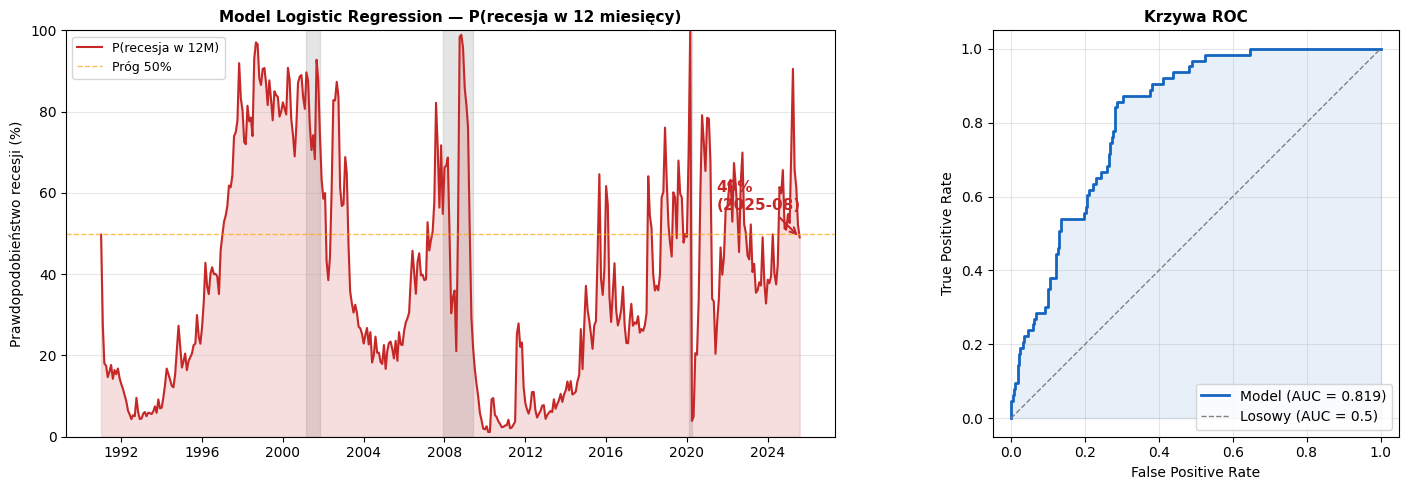

Zapisano: reports/08_recession_model.png


In [11]:
# Wykres 1: Prawdopodobieństwo recesji w czasie + ROC curve
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel lewy: prawdopodobieństwo recesji w czasie
ax = axes[0]
prob_series = pd.Series(y_prob, index=model_df.index)

# Szare pasy recesji
for _, r in recesje_df.iterrows():
    ax.axvspan(pd.Timestamp(r['start']), pd.Timestamp(r['end']),
               color='gray', alpha=0.2)

ax.plot(prob_series.index, prob_series * 100, color='#C62828', linewidth=1.5,
        label='P(recesja w 12M)')
ax.fill_between(prob_series.index, 0, prob_series * 100, alpha=0.15, color='#C62828')
ax.axhline(50, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Próg 50%')

# Aktualna wartość
last_prob_idx = prob_series.index[-1]
last_prob_val = prob_series.iloc[-1] * 100
ax.annotate(f'{last_prob_val:.0f}%\n({last_prob_idx.strftime("%Y-%m")})',
            xy=(last_prob_idx, last_prob_val),
            xytext=(-60, 20), textcoords='offset points',
            fontsize=11, fontweight='bold', color='#C62828',
            arrowprops=dict(arrowstyle='->', color='#C62828', lw=1.5))

ax.set_ylim(0, 100)
ax.set_ylabel('Prawdopodobieństwo recesji (%)')
ax.set_title('Model Logistic Regression — P(recesja w 12 miesięcy)',
             fontsize=11, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Panel prawy: ROC curve
ax = axes[1]
fpr, tpr, thresholds = roc_curve(y, y_prob)
auc = roc_auc_score(y, y_prob)

ax.plot(fpr, tpr, color='#1565C0', linewidth=2, label=f'Model (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Losowy (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#1565C0')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Krzywa ROC', fontsize=11, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_aspect('equal')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/08_recession_model.png', dpi=150, bbox_inches='tight')
plt.show()
print('Zapisano: reports/08_recession_model.png')

---
## 5. Podsumowanie Dnia 5

In [12]:
conn.close()

print('='*60)
print('DZIEŃ 5 UKOŃCZONY — ROZSZERZENIA')
print('='*60)
print()
print('1. VIX — Indeks strachu')
print('   - Pobrano z Yahoo Finance, dodano do bazy SQLite')
print('   - v_master zaktualizowany o kolumnę VIX')
print('   - Wykres z progami (spokój/strach/panika)')
print()
print('2. Heatmapa korelacji')
print('   - 11 wskaźników, korelacja Pearsona')
print('   - Identyfikacja redundantnych i niezależnych sygnałów')
print()
print('3. Timeline inwersja → recesja')
print('   - 4 epizody inwersji z liczbą miesięcy do recesji')
print('   - Ostatnia inwersja (2022-2024) bez recesji = soft landing')
print()
print('4. Logistic Regression')
print('   - 5 features → P(recesja w 12M)')
print('   - ROC AUC, współczynniki, wykres prawdopodobieństwa w czasie')
print()
print('Nowe pliki:')
for p in sorted(REP_DIR.glob('0[5-8]*')):
    print(f'  reports/{p.name}')
print(f'  data/raw/VIX.csv')

DZIEŃ 5 UKOŃCZONY — ROZSZERZENIA

1. VIX — Indeks strachu
   - Pobrano z Yahoo Finance, dodano do bazy SQLite
   - v_master zaktualizowany o kolumnę VIX
   - Wykres z progami (spokój/strach/panika)

2. Heatmapa korelacji
   - 11 wskaźników, korelacja Pearsona
   - Identyfikacja redundantnych i niezależnych sygnałów

3. Timeline inwersja → recesja
   - 4 epizody inwersji z liczbą miesięcy do recesji
   - Ostatnia inwersja (2022-2024) bez recesji = soft landing

4. Logistic Regression
   - 5 features → P(recesja w 12M)
   - ROC AUC, współczynniki, wykres prawdopodobieństwa w czasie

Nowe pliki:
  reports/05_vix.png
  reports/06_korelacje.png
  reports/07_timeline_inwersja_recesja.png
  reports/08_recession_model.png
  data/raw/VIX.csv
